# 7. Bivariate Analysis


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I compared pairs of variables to answer questions about genre, hook strength, pacing, episode duration, watch percentage, and intro skipping.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


In [2]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
# Engagement score based on the formula provided in the project brief.
# Watch percentage is already on a 0-100 scale, while the 1-10 content scores
# are multiplied by 5 before combining them.
df["engagement_score"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

df["engagement_score"].describe()

count    33171.000000
mean        70.734135
std         12.023213
min         30.000000
25%         62.500000
50%         71.000000
75%         79.500000
max        117.500000
Name: engagement_score, dtype: float64

In [3]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

## Watch Percentage by Genre

,genre,avg_watch_percentage
2,Comedy,64.286273
9,News,61.826087
11,Sci-Fi & Fantasy,57.425087
4,Documentary,57.253333
12,Soap,57.230539
13,Talk,57.227580
3,Crime,57.224622
1,Animation,57.114280
0,Action & Adventure,57.106695
10,Reality,56.881898


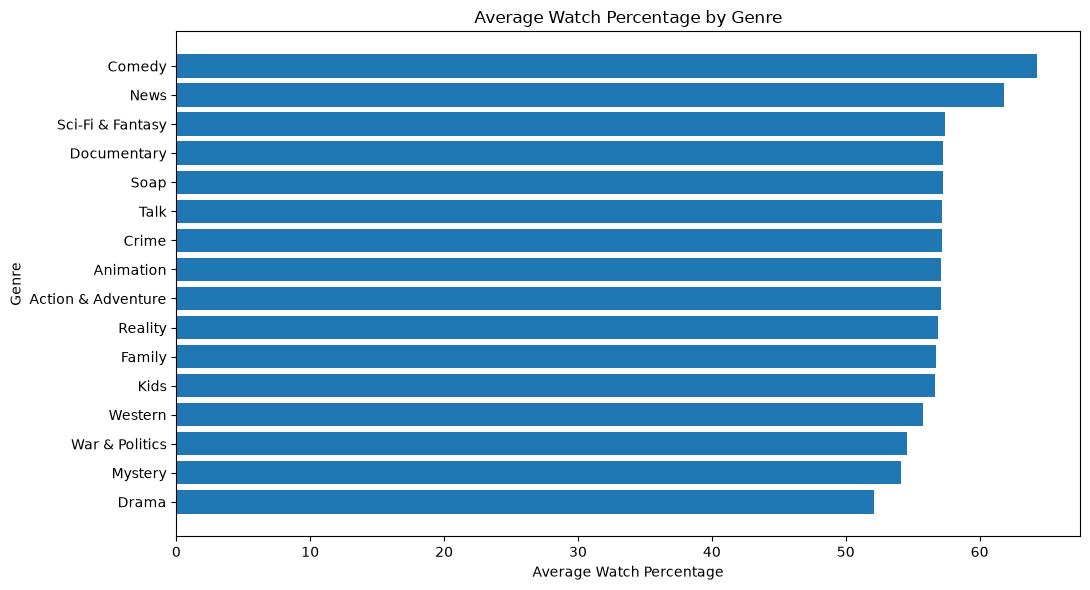

In [4]:
# PROCESS: Compare average watch completion across genres.
genre_watch = (
    df.groupby("genre", as_index=False)["avg_watch_percentage"]
    .mean()
    .sort_values("avg_watch_percentage", ascending=False)
)

display(genre_watch)

# Sort ascending for a horizontal bar chart so the strongest genre appears at the top.
plot_data = genre_watch.sort_values("avg_watch_percentage", ascending=True)

plt.figure(figsize=(11, 6))
plt.barh(plot_data["genre"], plot_data["avg_watch_percentage"])
plt.title("Average Watch Percentage by Genre")
plt.xlabel("Average Watch Percentage")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()
plt.close()

## Hook Strength vs Watch Percentage

,mean,median,count
hook_strength,,,
3,46.656029,48.0,5515
4,50.800921,52.0,5430
5,54.569292,56.0,5484
6,58.658223,60.0,5606
7,62.740734,64.0,5423
8,66.833725,68.0,5527
9,70.397590,72.0,83
10,73.543689,74.0,103


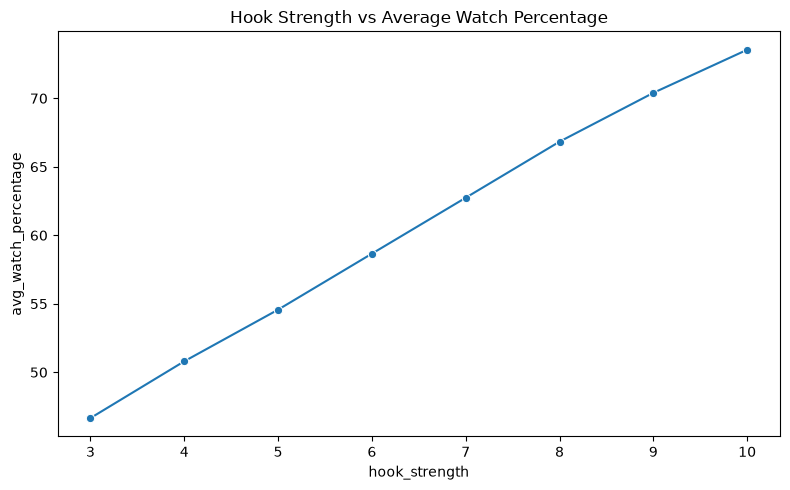

In [5]:
# PROCESS: Visualize the summarized relationship so patterns are easier to interpret.
hook_summary = df.groupby("hook_strength")["avg_watch_percentage"].agg(["mean", "median", "count"])
display(hook_summary)

plt.figure(figsize=(8, 5))
sns.lineplot(data=df.groupby("hook_strength", as_index=False)["avg_watch_percentage"].mean(),
             x="hook_strength", y="avg_watch_percentage", marker="o")
plt.title("Hook Strength vs Average Watch Percentage")
plt.tight_layout()
plt.show()
plt.close()

## Pacing vs Engagement

,pacing_score,engagement_score
0,3,57.531290
1,4,61.406109
2,5,70.413789
3,6,74.647224
4,7,78.256839
5,8,85.419974


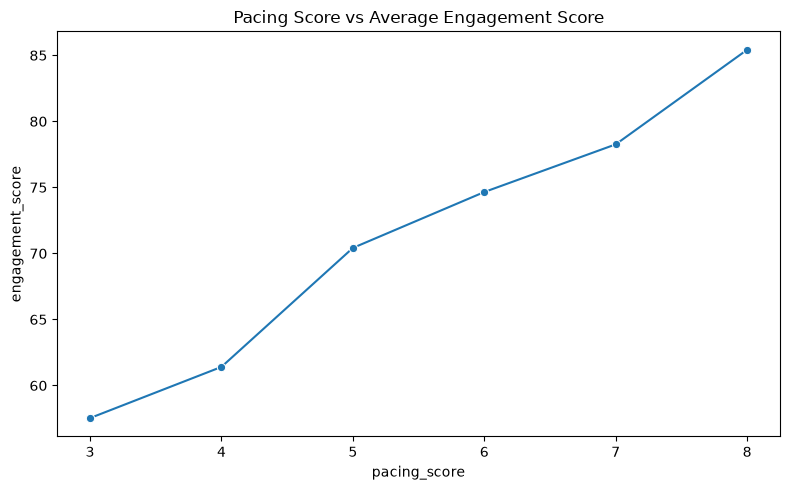

In [6]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
pacing_engagement = df.groupby("pacing_score", as_index=False)["engagement_score"].mean()
display(pacing_engagement)

plt.figure(figsize=(8, 5))
sns.lineplot(data=pacing_engagement, x="pacing_score", y="engagement_score", marker="o")
plt.title("Pacing Score vs Average Engagement Score")
plt.tight_layout()
plt.show()
plt.close()

## Episode Duration vs Watch Percentage

Pearson correlation: -0.0004


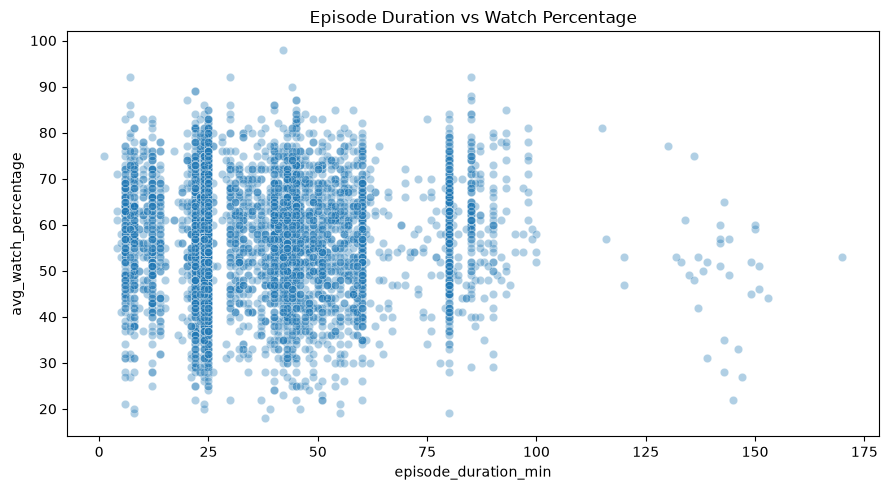

In [7]:
# PROCESS: Measure linear association with Pandas correlation; interpret association, not causation.
print("Pearson correlation:",
      round(df["episode_duration_min"].corr(df["avg_watch_percentage"]), 4))

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="episode_duration_min",
    y="avg_watch_percentage",
    alpha=0.35
)
plt.title("Episode Duration vs Watch Percentage")
plt.tight_layout()
plt.show()
plt.close()

## Intro Skipping by Genre

In [8]:
# PROCESS: Group episode-level records by genre and compare the requested performance metric.
skip_by_genre = (
    df.groupby("genre")["skip_intro"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("skip_intro_rate_pct")
    .reset_index()
)
display(skip_by_genre)

,genre,skip_intro_rate_pct
0,War & Politics,52.941176
1,Mystery,52.789700
2,Documentary,50.666667
3,Reality,50.661673
4,Animation,50.309134
5,Soap,50.299401
6,Talk,50.096432
7,Action & Adventure,49.628055
8,Sci-Fi & Fantasy,48.954704
9,Kids,48.417722


### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

## Key Interpretation

Hook strength is positively associated with watch completion (**r ≈ 0.552**), while episode duration has essentially no linear relationship with watch percentage (**r ≈ -0.0004**). The evidence suggests content structure and opening strength are more informative than runtime alone in this synthetic dataset.

## Genre Summary with Observation Counts

Group averages are more trustworthy when sample sizes are visible.  
This table combines episode counts, watch completion, engagement, and drop-off.

In [9]:
# Ensure the assignment-defined engagement index exists in this notebook.
df["engagement_index"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

genre_summary = (
    df.groupby("genre")
    .agg(
        episodes=("episode_number", "count"),
        mean_watch=("avg_watch_percentage", "mean"),
        median_watch=("avg_watch_percentage", "median"),
        avg_engagement=("engagement_index", "mean"),
        drop_off_rate=("drop_off", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

genre_summary["drop_off_rate_pct"] = (
    genre_summary["drop_off_rate"] * 100
)

display(genre_summary.round(2))

,episodes,mean_watch,median_watch,avg_engagement,drop_off_rate,drop_off_rate_pct
genre,,,,,,
Comedy,3067,64.29,64.0,77.38,0.03,2.87
News,46,61.83,61.5,74.55,0.04,4.35
Documentary,75,57.25,60.0,72.59,0.17,17.33
Crime,926,57.22,58.0,71.69,0.16,15.87
Family,208,56.71,57.0,71.51,0.13,12.98
Sci-Fi & Fantasy,574,57.43,58.0,71.23,0.13,13.07
Soap,334,57.23,57.5,71.22,0.13,13.17
Animation,10028,57.11,58.0,71.08,0.13,13.48
Kids,632,56.65,57.0,71.07,0.12,11.87


## Intro-Skip Rate by Genre

Because `skip_intro` is binary, its group mean is the skip rate.  
Percentages are more useful than raw counts when genre sample sizes differ.

In [10]:
intro_skip_analysis = (
    df.groupby("genre")
    .agg(
        episodes=("skip_intro", "count"),
        skip_rate=("skip_intro", "mean")
    )
)

intro_skip_analysis["skip_rate_pct"] = (
    intro_skip_analysis["skip_rate"] * 100
)

display(
    intro_skip_analysis
    .sort_values("skip_rate_pct", ascending=False)
    .round(2)
)

,episodes,skip_rate,skip_rate_pct
genre,,,
War & Politics,51,0.53,52.94
Mystery,233,0.53,52.79
Documentary,75,0.51,50.67
Reality,4005,0.51,50.66
Animation,10028,0.50,50.31
Soap,334,0.50,50.30
Talk,2074,0.50,50.10
Action & Adventure,4705,0.50,49.63
Sci-Fi & Fantasy,574,0.49,48.95


In [11]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
